
![](img/logoitqv1.jpg)

## 01PAO26-26 - Regresion logistica 2 

![](img/python_logo.png)


*Alysson Guaman*

**Repositorio:** [Github](https://github.com/a12lj/machine-learning.git)
# 1. Preprocesamiento de Datos

El **preprocesamiento de datos** es una de las etapas más importantes dentro del proceso de Machine Learning, ya que permite preparar la información antes de entrenar un modelo.

En esta práctica se trabajará con el conjunto de datos **Iris**, realizando un análisis exploratorio y aplicando dos técnicas fundamentales para el escalado de variables: la **normalización** y la **estandarización**. Finalmente, se compararán visualmente los resultados para comprender el efecto de cada transformación sobre los datos.

---

# 1. Ejercicio Práctico

## Normalización y Estandarización de Datos en Inteligencia Artificial

**Nombre:** Alysson Guaman

**Fecha:** 19 de julio de 2026

---

# 2. Práctica Académica

## 2.1 Análisis y aplicación de técnicas de normalización y estandarización de datos para modelos de aprendizaje automático

### Objetivo General

Aplicar técnicas de **normalización** y **estandarización** de datos utilizando herramientas de Python, con el propósito de comprender su importancia dentro del preprocesamiento de datos y analizar su impacto en el desempeño de los modelos de aprendizaje automático.

### Objetivos Específicos

- Identificar las diferencias de escala existentes entre las variables numéricas de un conjunto de datos.
- Aplicar la técnica de **Normalización Min-Max** para escalar los datos dentro de un rango determinado.
- Aplicar la técnica de **Estandarización (Z-Score)** para centrar y escalar las variables.
- Analizar la importancia del preprocesamiento de datos en el entrenamiento de modelos de Inteligencia Artificial.

### Fundamentación Teórica

En el ámbito del **Machine Learning**, los algoritmos de aprendizaje suelen verse afectados por la diferencia de escala entre las variables. Cuando una característica posee valores considerablemente mayores que las demás, puede influir excesivamente en el proceso de aprendizaje del modelo, generando resultados poco precisos o incluso sesgados.

Para reducir este problema se emplean técnicas de escalado de datos, entre las que destacan:

- **Normalización:** transforma los datos a un rango específico, generalmente entre **0 y 1**.
- **Estandarización:** ajusta los datos para que tengan una **media igual a 0** y una **desviación estándar igual a 1**.

Estas técnicas son ampliamente utilizadas en algoritmos de aprendizaje automático como:

- K-Nearest Neighbors (KNN)
- Regresión Logística
- Redes Neuronales

### Escenario de la Práctica

Una empresa dedicada al análisis de datos desea desarrollar modelos predictivos utilizando información de sus clientes. Durante el análisis inicial se detectó que las variables del conjunto de datos presentan diferentes escalas, situación que puede afectar el rendimiento de los modelos de Inteligencia Artificial.

Como analista de datos, se requiere aplicar técnicas de preprocesamiento para preparar correctamente la información antes del entrenamiento de los modelos.

### Conjunto de Datos

Durante la práctica se trabajará con los siguientes conjuntos de datos:

- **Dataset 1:** Iris Dataset (conceptual).
- **Dataset 2:** California Housing Dataset (aplicación real).

---

## 1. Preparación del Entorno

Antes de comenzar con el análisis de datos es necesario importar las librerías que se utilizarán durante toda la práctica.

Además, se configurará la API de **Kaggle** para descargar automáticamente el conjunto de datos **Iris**, el cual servirá como base para aplicar las técnicas de normalización y estandarización.

In [6]:
# ==========================================================
# Importación de librerías
# ==========================================================

# Pandas permite trabajar con tablas de datos (DataFrames).
import pandas as pd

# NumPy facilita operaciones matemáticas y manejo de arreglos.
import numpy as np

# Permite descomprimir el archivo descargado desde Kaggle.
import zipfile

# Seaborn se utilizará para realizar visualizaciones estadísticas.
import seaborn as sns

# Matplotlib permite generar gráficos.
import matplotlib.pyplot as plt

# Contiene herramientas de preprocesamiento como normalización
# y estandarización.
from sklearn import preprocessing

# Librería para trabajar con archivos y directorios.
import os

## Configuración de Kaggle

Para obtener el conjunto de datos se utilizará la API oficial de Kaggle.

En primer lugar se configura la ubicación del archivo **kaggle.json**, posteriormente se crea la carpeta donde se almacenará el dataset descargado y finalmente se descarga y descomprime el archivo.

In [7]:
# ==========================================================
# Configuración de la API de Kaggle
# ==========================================================

# Indicamos dónde se encuentra el archivo kaggle.json.
os.environ["KAGGLE_CONFIG_DIR"] = r"C:\Users\pc\.kaggle"


# ==========================================================
# Crear carpeta para almacenar el dataset
# ==========================================================

# Si la carpeta no existe, Python la crea automáticamente.
os.makedirs("dataset", exist_ok=True)


# ==========================================================
# Descargar el Iris Dataset desde Kaggle
# ==========================================================

# Descargamos el conjunto de datos.
!kaggle datasets download -d uciml/iris


# ==========================================================
# Descomprimir el archivo descargado
# ==========================================================

# Extraemos el contenido del archivo ZIP dentro de la carpeta dataset.
with zipfile.ZipFile("iris.zip", "r") as zip_ref:
    zip_ref.extractall("dataset")

Dataset URL: https://www.kaggle.com/datasets/uciml/iris
License(s): CC0-1.0




  0%|          | 0.00/3.60k [00:00<?, ?B/s]
100%|##########| 3.60k/3.60k [00:00<00:00, 1.37MB/s]


## Carga del conjunto de datos

Una vez descargado el dataset, se carga el archivo **Iris.csv** dentro de un DataFrame de Pandas para comenzar con el análisis exploratorio de la información.

In [12]:
# ==========================================================
# Carga del conjunto de datos
# ==========================================================

# Leemos el archivo CSV descargado desde Kaggle.
df = pd.read_csv("dataset/Iris.csv")


# ==========================================================
# Visualización de los primeros registros
# ==========================================================

# Mostramos las primeras cinco filas del conjunto de datos.
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


## Limpieza del conjunto de datos

Como parte del proceso de preprocesamiento, se elimina la columna **Id**, ya que únicamente identifica cada registro y no aporta información relevante para el entrenamiento de un modelo de aprendizaje automático.

In [13]:
# ==========================================================
# Eliminación de columnas innecesarias
# ==========================================================

# Verificamos si existe la columna Id.
if "Id" in df.columns:

    # Eliminamos la columna porque no aporta información útil.
    df = df.drop(columns=["Id"])


# ==========================================================
# Visualización del DataFrame actualizado
# ==========================================================

df.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


## Exploración inicial del conjunto de datos

Antes de aplicar cualquier técnica de preprocesamiento es importante conocer la estructura del dataset.

Para ello se revisará:

- El tipo de dato de cada variable.
- El número de registros.
- La existencia de valores nulos.

In [14]:
# ==========================================================
# Información general del dataset
# ==========================================================

# Mostramos la estructura del conjunto de datos.
df.info()


# ==========================================================
# Verificación de valores nulos
# ==========================================================

# Contamos la cantidad de datos faltantes por columna.
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   SepalLengthCm  150 non-null    float64
 1   SepalWidthCm   150 non-null    float64
 2   PetalLengthCm  150 non-null    float64
 3   PetalWidthCm   150 non-null    float64
 4   Species        150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64

## Separación de variables

Para construir modelos de aprendizaje automático es necesario separar las variables independientes (**X**) de la variable objetivo (**y**).

En este caso:

- **X** contiene las características de cada flor.
- **y** contiene la especie correspondiente.

In [15]:
# ==========================================================
# Separación de variables
# ==========================================================

# Variables de entrada.
X = df.drop(columns=["Species"])

# Variable objetivo.
y = df["Species"]

## Análisis Exploratorio

Finalmente se obtiene un resumen estadístico de las variables numéricas del conjunto de datos, permitiendo conocer medidas como la media, desviación estándar, valores mínimos, máximos y cuartiles.

In [16]:
# ==========================================================
# Estadísticas descriptivas
# ==========================================================

# Generamos un resumen estadístico del conjunto de datos.
X.describe()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


## Conclusión del Análisis Exploratorio

Al analizar las estadísticas descriptivas del conjunto de datos se observa que las variables presentan diferentes rangos de valores.

Por ejemplo:

- **PetalLengthCm** posee valores comprendidos aproximadamente entre **1.0 y 6.9**, mostrando una variabilidad considerable.
- **SepalWidthCm** presenta un rango menor, aproximadamente entre **2.0 y 4.4**, por lo que su dispersión es inferior.

Estas diferencias indican que las variables **no se encuentran en la misma escala**, situación que puede afectar el desempeño de diversos algoritmos de Machine Learning.

En modelos basados en distancias, como **K-Nearest Neighbors (KNN)**, las variables con valores más grandes ejercen una mayor influencia durante el entrenamiento, provocando que el modelo tome decisiones sesgadas.

Para evitar este problema se emplean técnicas de **preprocesamiento**, entre las que destacan:

- **Normalización (Min-Max)**
- **Estandarización (Z-Score)**

Ambas técnicas permiten que todas las variables tengan una escala comparable, evitando que una característica domine sobre las demás y favoreciendo un mejor rendimiento de los modelos predictivos.

## Visualización de los Datos Originales

Antes de aplicar cualquier técnica de escalado, es importante observar la distribución de las variables mediante un diagrama de cajas (*Boxplot*).

Este gráfico permite comparar la dispersión de cada característica e identificar visualmente las diferencias de escala existentes entre ellas.

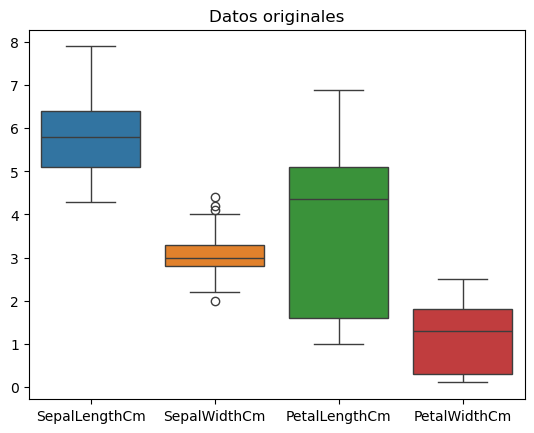

In [17]:
# ==========================================================
# Visualización de los datos originales
# ==========================================================

# Dibujamos un diagrama de cajas para observar la escala
# y dispersión de las variables originales.
sns.boxplot(data=X)

# Agregamos un título al gráfico.
plt.title("Datos originales")

# Mostramos la figura.
plt.show()

### Interpretación del gráfico

El diagrama de cajas muestra que las variables presentan diferentes rangos y niveles de dispersión.

Estas diferencias pueden ocasionar que algunos algoritmos de aprendizaje automático otorguen mayor importancia a determinadas variables únicamente debido a su escala, por lo que resulta necesario aplicar técnicas de normalización o estandarización antes del entrenamiento del modelo.

## Normalización mediante Min-Max

La **normalización** transforma cada variable para que sus valores se encuentren dentro de un rango comprendido entre **0 y 1**.

Esta técnica conserva la forma de la distribución original, pero elimina las diferencias de escala entre las variables.

In [18]:
# ==========================================================
# Normalización Min-Max
# ==========================================================

# Creamos el objeto encargado de realizar la normalización.
normalizer = preprocessing.MinMaxScaler()

# Ajustamos el modelo y transformamos los datos.
X_norm = normalizer.fit_transform(X)

# Convertimos el resultado nuevamente a un DataFrame.
X_norm = pd.DataFrame(
    X_norm,
    columns=X.columns
)

# Visualizamos los primeros registros.
X_norm.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
0,0.222222,0.625000,0.067797,0.041667
1,0.166667,0.416667,0.067797,0.041667
2,0.111111,0.500000,0.050847,0.041667
3,0.083333,0.458333,0.084746,0.041667
4,0.194444,0.666667,0.067797,0.041667


### Estadísticas del conjunto normalizado

A continuación se presentan las estadísticas descriptivas de los datos una vez aplicada la normalización.

In [19]:
# ==========================================================
# Estadísticas del conjunto normalizado
# ==========================================================

X_norm.describe()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000
mean,0.428704,0.439167,0.467571,0.457778
std,0.230018,0.180664,0.299054,0.317984
min,0.000000,0.000000,0.000000,0.000000
25%,0.222222,0.333333,0.101695,0.083333
50%,0.416667,0.416667,0.567797,0.500000
75%,0.583333,0.541667,0.694915,0.708333
max,1.000000,1.000000,1.000000,1.000000


## Estandarización mediante Z-Score

La **estandarización** transforma las variables para que tengan:

- Media igual a **0**
- Desviación estándar igual a **1**

Esta técnica es ampliamente utilizada en algoritmos que asumen distribuciones aproximadamente normales.

In [20]:
# ==========================================================
# Estandarización
# ==========================================================

# Creamos el objeto encargado de estandarizar los datos.
standardizer = preprocessing.StandardScaler()

# Ajustamos el modelo y transformamos las variables.
X_std = standardizer.fit_transform(X)

# Convertimos el resultado en un DataFrame.
X_std = pd.DataFrame(
    X_std,
    columns=X.columns
)

# Visualizamos las primeras filas.
X_std.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
0,-0.900681,1.032057,-1.341272,-1.312977
1,-1.143017,-0.124958,-1.341272,-1.312977
2,-1.385353,0.337848,-1.398138,-1.312977
3,-1.506521,0.106445,-1.284407,-1.312977
4,-1.021849,1.263460,-1.341272,-1.312977


## Comparación Visual

Finalmente se comparan los datos originales con los datos normalizados y estandarizados mediante diagramas de cajas.

Esta comparación permite observar claramente cómo las técnicas de escalado reducen las diferencias de magnitud entre las variables.

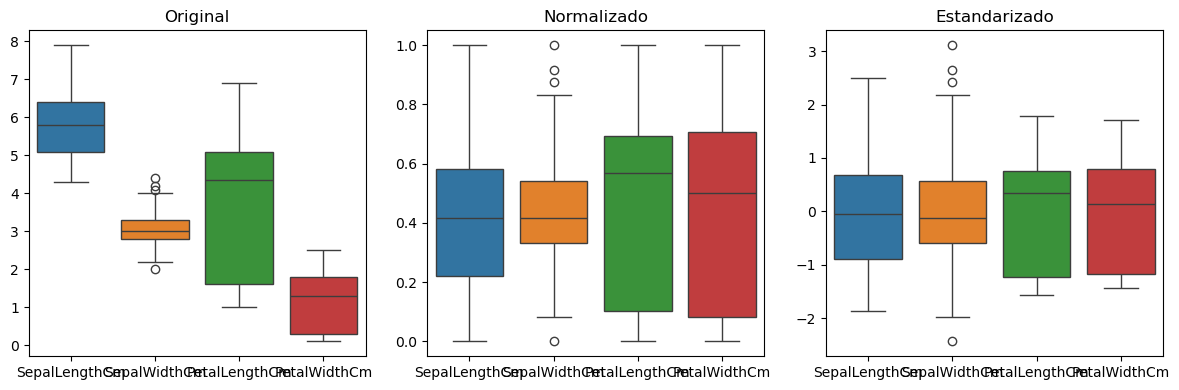

In [21]:
# ==========================================================
# Comparación visual de los tres conjuntos de datos
# ==========================================================

# Definimos el tamaño de la figura.
plt.figure(figsize=(12, 4))


# -------------------------------
# Datos originales
# -------------------------------
plt.subplot(1, 3, 1)

sns.boxplot(data=X)

plt.title("Original")


# -------------------------------
# Datos normalizados
# -------------------------------
plt.subplot(1, 3, 2)

sns.boxplot(data=X_norm)

plt.title("Normalizado")


# -------------------------------
# Datos estandarizados
# -------------------------------
plt.subplot(1, 3, 3)

sns.boxplot(data=X_std)

plt.title("Estandarizado")


# Ajustamos automáticamente los espacios.
plt.tight_layout()

# Mostramos la comparación.
plt.show()

# Conclusiones

Durante esta práctica se analizaron las diferencias de escala presentes en el conjunto de datos **Iris**, comprobando que las variables poseen rangos y distribuciones distintas.

Posteriormente se aplicaron las técnicas de **normalización Min-Max** y **estandarización Z-Score**, observando cómo ambas permiten reducir las diferencias de magnitud entre las características, favoreciendo un tratamiento más equilibrado de la información.

Finalmente, mediante la comparación gráfica se evidenció la importancia del preprocesamiento de datos dentro de los proyectos de **Machine Learning**, ya que estas técnicas contribuyen a mejorar el desempeño y la estabilidad de numerosos algoritmos de aprendizaje automático.